Import all the classes we need.

In [38]:
from PriceDataLoader import PriceDataLoader
from WeatherDataLoader import WeatherDataLoader
from models.CNN import *
from models.FFN import *
import torch
from models.CointegrationResidualGenerator import CointegrationResidualGenerator
from PortfolioOptimizer import PortfolioOptimizer
from Trainer import Trainer
from PortfolioOptimizer import PortfolioOptimizer
from DataPreparation import DataPreparation
import pandas as pd
from datetime import datetime, timedelta
import os
import numpy as np
import matplotlib.pyplot as plt



Set the device

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else
                        "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Load the data with weather data

In [17]:
def generate_all_data_via_rolling_windows(
    price_parser,
    weather_parser,
    countries_list,
    weather_features,
    window_size=30,
    cointegration_period=250,
    stride=5,
    start_date="2015-01-01",
    end_date="2024-12-31",
    use_weather=True
):
    """
    Generates train/val/test data using a rolling cointegration window.

    Parameters:
        price_parser: PriceDataLoader object
        weather_parser: WeatherDataLoader object
        cointegration_period: int, window size for cointegration period (default=250)
        stride: int, how much to roll the window forward each time (default=5)
        start_date: str, beginning of date range for rolling windows
        end_date: str, end of date range for rolling windows

    Returns:
        Tuple of lists of train/val/test data and returns:
        (
            all_train_data, all_train_returns,
            all_val_data, all_val_returns,
            all_test_data, all_test_returns
        )
    """

    all_train_data, all_train_returns = [], []
    all_val_data, all_val_returns = [], []
    all_test_data, all_test_returns = [], []

    current_start = pd.to_datetime(start_date)
    final_end = pd.to_datetime(end_date)

    while current_start + timedelta(days=cointegration_period + 30 + 1) <= final_end:
        current_end = current_start + timedelta(days=cointegration_period)
        date_range = f"{current_start.date()},{current_end.date()}"
        print(f"----------------------Processing date range: {date_range}----------------------")

        # countries_list = list(set(price_parser.get_countries_with_complete_data(date_range)) &
        #                       set(weather_parser.get_country_list()))
        if not countries_list:
            current_start += timedelta(days=stride)
            continue

        # Generate price matrix
        price_matrix = price_parser.get_price_matrix(
            time_range=date_range,
            countries=countries_list,
            fill_method="ffill"
        )
        # print(f"Shape of price_matrix: {price_matrix.shape}")

        # Compute returns
        returns = price_matrix.pct_change().dropna()
        # print(f"Shape of returns: {returns.shape}")

        # Generate asset residuals using cointegration
        residual_generator = CointegrationResidualGenerator(price_matrix)
        residual_generator.compute_all_asset_residuals()
        asset_residuals = residual_generator.get_asset_residuals()

        # print(f"Number of total features (price + weather): {len(weather_features) * len(countries_list) + 1}")

        # Generate weather matrix
        weather_matrix = weather_parser.get_weather_matrix(
            time_range=date_range,
            countries=countries_list,
            fill_method="ffill",
            features=weather_features
        )
        # print(f"Shape of weather_matrix: {weather_matrix.shape}")

        dp = DataPreparation(
            price_residuals=asset_residuals,
            weather_data=weather_matrix,
            countries=countries_list,
            weather_features=weather_features
        )
        window_size = 30
        inner_stride = 1
        combined_data = dp.prepare_rolling_windows(window_size=window_size, stride=inner_stride) 
        # [num_samples, num_features, window_size]
        
        # Drop the weather feature if not using weather data
        if not use_weather:
            combined_data = combined_data[:, :len(countries_list), :]  # Drop weather features

        next_day_returns = dp.prepare_next_day_returns(returns=returns, window_size=window_size, stride=inner_stride)
        # [num_samples, num_countries]
        
        # Split the data in time-series
        (train_data, train_returns), (val_data, val_returns), (test_data, test_returns) = \
        dp.create_train_val_test_split(combined_data=combined_data, next_day_returns=next_day_returns)

        if train_data is not None and len(train_data) > 0:
            all_train_data.extend(train_data)
            all_train_returns.extend(train_returns)

        if val_data is not None and len(val_data) > 0:
            all_val_data.extend(val_data)
            all_val_returns.extend(val_returns)

        if test_data is not None and len(test_data) > 0:
            all_test_data.extend(test_data)
            all_test_returns.extend(test_returns)

        current_start += timedelta(days=stride)

    return (
        all_train_data, all_train_returns,
        all_val_data, all_val_returns,
        all_test_data, all_test_returns
    )



In [18]:
price_parser = PriceDataLoader(file_path="../data/european_wholesale_electricity_price_data_daily.csv")
weather_parser = WeatherDataLoader(file_path="../data/aggregated_weather.csv")

data_path = "data/all_data.pt"
force_regenerate = True

if os.path.exists(data_path) and not force_regenerate:
    # Load pre-saved data
    print("Loading pre-saved data...")
    checkpoint = torch.load(data_path)
    all_train_data = checkpoint["train_data"]
    all_train_returns = checkpoint["train_returns"]
    all_val_data = checkpoint["val_data"]
    all_val_returns = checkpoint["val_returns"]
    all_test_data = checkpoint["test_data"]
    all_test_returns = checkpoint["test_returns"]
else:
    # Generate data
    print("Generating data...")
    
    # Define the time range and valid countries
    start_date="2015-01-01"
    end_date="2024-12-31"
    time_range = f"{start_date},{end_date}"
    countries_list = list(set(price_parser.get_countries_with_complete_data(time_range)) & 
                     set(weather_parser.get_country_list()))
    
    # Define weather features
    weather_features = [
        'temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max',
        'precipitation_mean', 'precipitation_min', 'precipitation_max',
        'wind_speed_mean', 'wind_speed_min', 'wind_speed_max'
    ]

    # Define the window size
    window_size = 30 

    # Define to include weather data or not
    use_weather = True  # Set to True if you want to include weather data

    # Generate all data using rolling windows
    all_train_data, all_train_returns, all_val_data, all_val_returns, all_test_data, all_test_returns = generate_all_data_via_rolling_windows(
        price_parser,
        weather_parser,
        countries_list=countries_list,
        weather_features=weather_features,
        window_size=30,
        cointegration_period=365,
        stride=182, # 6 months stride
        start_date=start_date,
        end_date=end_date,
        use_weather=use_weather
    )

    # Save the result
    os.makedirs("data", exist_ok=True)
    torch.save({
        "train_data": all_train_data,
        "train_returns": all_train_returns,
        "val_data": all_val_data,
        "val_returns": all_val_returns,
        "test_data": all_test_data,
        "test_returns": all_test_returns
    }, data_path)
 
# Convert to tensors
train_data_with_weather_tensor = torch.FloatTensor(all_train_data).to(device)
train_returns_with_weather_tensor = torch.FloatTensor(all_train_returns).to(device)
val_data_with_weather_tensor = torch.FloatTensor(all_val_data).to(device)
val_returns_with_weather_tensor = torch.FloatTensor(all_val_returns).to(device)
test_data_with_weather_tensor = torch.FloatTensor(all_test_data).to(device)
test_returns_with_weather_tensor = torch.FloatTensor(all_test_returns).to(device)


Data loaded successfully from ../data/european_wholesale_electricity_price_data_daily.csv
Weather data loaded successfully from ../data/aggregated_weather.csv
Generating data...
----------------------Processing date range: 2015-01-01,2016-01-01----------------------


KeyboardInterrupt: 

In [ ]:
print(f"Train data shape: {train_data_with_weather_tensor.shape}") # [samples, num_features, window size]
print(f"Train returns shape: {train_returns_with_weather_tensor.shape}") # [samples, num_countries (returns)]

Train data shape: torch.Size([4103, 240, 30])
Train returns shape: torch.Size([4103, 24])


Load the data without weather data

In [19]:
price_parser = PriceDataLoader(file_path="../data/european_wholesale_electricity_price_data_daily.csv")
weather_parser = WeatherDataLoader(file_path="../data/aggregated_weather.csv")

data_path = "data/all_data.pt"
force_regenerate = True

if os.path.exists(data_path) and not force_regenerate:
    # Load pre-saved data
    print("Loading pre-saved data...")
    checkpoint = torch.load(data_path)
    all_train_data = checkpoint["train_data"]
    all_train_returns = checkpoint["train_returns"]
    all_val_data = checkpoint["val_data"]
    all_val_returns = checkpoint["val_returns"]
    all_test_data = checkpoint["test_data"]
    all_test_returns = checkpoint["test_returns"]
else:

    # Define to include weather data or not
    use_weather = False  # Set to True if you want to include weather data

    # Generate all data using rolling windows
    all_train_data, all_train_returns, all_val_data, all_val_returns, all_test_data, all_test_returns = generate_all_data_via_rolling_windows(
        price_parser,
        weather_parser,
        countries_list=countries_list,
        weather_features=weather_features,
        window_size=30,
        cointegration_period=365,
        stride=182, # 6 months stride
        start_date=start_date,
        end_date=end_date,
        use_weather=use_weather
    )

    # Save the result
    os.makedirs("data", exist_ok=True)
    torch.save({
        "train_data": all_train_data,
        "train_returns": all_train_returns,
        "val_data": all_val_data,
        "val_returns": all_val_returns,
        "test_data": all_test_data,
        "test_returns": all_test_returns
    }, data_path)
 
# Convert to tensors
train_data_without_weather_tensor = torch.FloatTensor(all_train_data).to(device)
train_returns_without_weather_tensor = torch.FloatTensor(all_train_returns).to(device)
val_data_without_weather_tensor = torch.FloatTensor(all_val_data).to(device)
val_returns_without_weather_tensor = torch.FloatTensor(all_val_returns).to(device)
test_data_without_weather_tensor = torch.FloatTensor(all_test_data).to(device)
test_returns_without_weather_tensor = torch.FloatTensor(all_test_returns).to(device)


Data loaded successfully from ../data/european_wholesale_electricity_price_data_daily.csv
Weather data loaded successfully from ../data/aggregated_weather.csv
----------------------Processing date range: 2015-01-01,2016-01-01----------------------
----------------------Processing date range: 2015-07-02,2016-07-01----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


----------------------Processing date range: 2015-12-31,2016-12-30----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


KeyboardInterrupt: 

In [ ]:
print(f"Train data shape: {train_data_without_weather_tensor.shape}") # [samples, num_features, window size]
print(f"Train returns shape: {train_returns_without_weather_tensor.shape}") # [samples, num_countries (returns)]

Train data shape: torch.Size([4103, 24, 30])
Train returns shape: torch.Size([4103, 24])


#### Load all the models

with transformer without weather

In [268]:
# Reconstruct model with same architecture
use_weather = False
use_transformer = True
if use_weather:
    num_weather_features = len(weather_features)
else:
    num_weather_features = 0
portfolio_optimizer_wt_wow = PortfolioOptimizer(
    window_size=window_size,
    num_countries=len(countries_list),
    num_weather_features=num_weather_features,
    num_filters=16,
    filter_size=5,
    hidden_dim=64,
    num_heads=4,
    use_transformer=use_transformer,
    device=device
)

# Load saved weights
portfolio_optimizer_wt_wow.cnn_model.load_state_dict(torch.load("with_transformer_without_weather_cnn_model.pt", map_location=device))
portfolio_optimizer_wt_wow.ffn_model.load_state_dict(torch.load("with_transformer_without_weather_ffn_model.pt", map_location=device))
portfolio_optimizer_wt_wow.transformer_model.load_state_dict(torch.load("with_transformer_without_weather_transformer_model.pt", map_location=device))


C:\Users\Volter\AppData\Local\Temp\ipykernel_40868\4109162619.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  portfolio_optimizer_wt_wow.cnn_model.load_state_dict(torch

<All keys matched successfully>

with transformer with weather

In [266]:
# Reconstruct model with same architecture
use_weather = True
use_transformer = True
if use_weather:
    num_weather_features = len(weather_features)
else:
    num_weather_features = 0
portfolio_optimizer_wt_ww = PortfolioOptimizer(
    window_size=window_size,
    num_countries=len(countries_list),
    num_weather_features=num_weather_features,
    num_filters=8,
    filter_size=3,
    hidden_dim=128,
    num_heads=4,
    use_transformer=use_transformer,
    device=device
)

# Load saved weights
portfolio_optimizer_wt_ww.cnn_model.load_state_dict(torch.load("with_transformer_with_weather_cnn_model.pt", map_location=device))
portfolio_optimizer_wt_ww.ffn_model.load_state_dict(torch.load("with_transformer_with_weather_ffn_model.pt", map_location=device))
portfolio_optimizer_wt_ww.transformer_model.load_state_dict(torch.load("with_transformer_with_weather_transformer_model.pt", map_location=device))


C:\Users\Volter\AppData\Local\Temp\ipykernel_40868\3535512432.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  portfolio_optimizer_wt_ww.cnn_model.load_state_dict(torch.

<All keys matched successfully>

without transformer without weather

In [265]:
# Reconstruct model with same architecture
use_weather = False
use_transformer = False
if use_weather:
    num_weather_features = len(weather_features)
else:
    num_weather_features = 0
portfolio_optimizer_wot_wow = PortfolioOptimizer(
    window_size=window_size,
    num_countries=len(countries_list),
    num_weather_features=num_weather_features,
    num_filters=8,
    filter_size=7,
    hidden_dim=128,
    num_heads=4,
    use_transformer=use_transformer,
    device=device
)

# Load saved weights
portfolio_optimizer_wot_wow.cnn_model.load_state_dict(torch.load("without_transformer_without_weather_cnn_model.pt", map_location=device))
portfolio_optimizer_wot_wow.ffn_model.load_state_dict(torch.load("without_transformer_without_weather_ffn_model.pt", map_location=device))


C:\Users\Volter\AppData\Local\Temp\ipykernel_40868\4260631356.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  portfolio_optimizer_wot_wow.cnn_model.load_state_dict(torc

<All keys matched successfully>

without transformer without weather

In [264]:
# Reconstruct model with same architecture
use_weather = True
use_transformer = False
if use_weather:
    num_weather_features = len(weather_features)
else:
    num_weather_features = 0
portfolio_optimizer_wot_ww = PortfolioOptimizer(
    window_size=window_size,
    num_countries=len(countries_list),
    num_weather_features=num_weather_features,
    num_filters=8,
    filter_size=3,
    hidden_dim=128,
    num_heads=4,
    use_transformer=use_transformer,
    device=device
)

# Load saved weights
portfolio_optimizer_wot_ww.cnn_model.load_state_dict(torch.load("without_transformer_with_weather_cnn_model.pt", map_location=device))
portfolio_optimizer_wot_ww.ffn_model.load_state_dict(torch.load("without_transformer_with_weather_ffn_model.pt", map_location=device))


C:\Users\Volter\AppData\Local\Temp\ipykernel_40868\3272037471.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  portfolio_optimizer_wot_ww.cnn_model.load_state_dict(torch

<All keys matched successfully>

Add all models into a single set

In [241]:
# Split the portfolio optimizers into two list of no weather and with weather
portfolio_optimizers_ww = [
    portfolio_optimizer_wt_ww,
    portfolio_optimizer_wot_ww
]

portfolio_optimizers_wow = [
    portfolio_optimizer_wt_wow,
    portfolio_optimizer_wot_wow
]


#### Test data returns back-test

In [168]:
def generate_returns_back_test_data(
    price_parser,
    weather_parser,
    countries_list,
    weather_features,
    window_size=30,
    cointegration_period=365,
    stride=1,
    start_date="2022-12-31",
    end_date="2024-12-31",
    use_weather=True
):
    """
    Generates train/val/test data using a rolling cointegration window.

    Parameters:
        price_parser: PriceDataLoader object
        weather_parser: WeatherDataLoader object
        cointegration_period: int, window size for cointegration period (default=250)
        stride: int, how much to roll the window forward each time (default=5)
        start_date: str, beginning of date range for rolling windows
        end_date: str, end of date range for rolling windows

    Returns:
        Tuple of lists of train/val/test data and returns:
        (
            all_train_data, all_train_returns,
            all_val_data, all_val_returns,
            all_test_data, all_test_returns
        )
    """

    all_model_inputs, all_model_returns = [], []

    current_start = pd.to_datetime(start_date)
    final_end = pd.to_datetime(end_date)

    while current_start + timedelta(days=cointegration_period + 1) <= final_end:
        current_end = current_start + timedelta(days=cointegration_period)
        date_range = f"{current_start.date()},{current_end.date()}"
        print(f"----------------------Processing date range: {date_range}----------------------")

        # countries_list = list(set(price_parser.get_countries_with_complete_data(date_range)) &
        #                       set(weather_parser.get_country_list()))
        if not countries_list:
            current_start += timedelta(days=stride)
            continue

        # Generate price matrix
        price_matrix = price_parser.get_price_matrix(
            time_range=date_range,
            countries=countries_list,
            fill_method="ffill"
        )
        # print(f"Shape of price_matrix: {price_matrix.shape}")

        # Compute returns
        returns = price_matrix.pct_change().dropna()
        # print(f"Shape of returns: {returns.shape}")

        # Generate asset residuals using cointegration
        residual_generator = CointegrationResidualGenerator(price_matrix)
        residual_generator.compute_all_asset_residuals()
        asset_residuals = residual_generator.get_asset_residuals()

        # print(f"Number of total features (price + weather): {len(weather_features) * len(countries_list) + 1}")

        # Generate weather matrix
        weather_matrix = weather_parser.get_weather_matrix(
            time_range=date_range,
            countries=countries_list,
            fill_method="ffill",
            features=weather_features
        )
        # print(f"Shape of weather_matrix: {weather_matrix.shape}")

        dp = DataPreparation(
            price_residuals=asset_residuals,
            weather_data=weather_matrix,
            countries=countries_list,
            weather_features=weather_features
        )
        window_size = 30
        inner_stride = 1
        combined_data = dp.prepare_rolling_windows(window_size=window_size, stride=inner_stride) 
        # [num_samples, num_features, window_size]
        
        # Drop the weather feature if not using weather data
        if not use_weather:
            combined_data = combined_data[:, :len(countries_list), :]  # Drop weather features

        next_day_returns = dp.prepare_next_day_returns(returns=returns, window_size=window_size, stride=inner_stride)
        # [num_samples, num_countries]
        
        # Get the last entries of combined_data and next_day_returns
        if combined_data is not None and len(combined_data) > 0:
            last_combined_data = combined_data[-182]
            all_model_inputs.append(last_combined_data)
        if next_day_returns is not None and len(next_day_returns) > 0:
            last_next_day_returns = next_day_returns[-182]
            all_model_returns.append(last_next_day_returns)

        current_start += timedelta(days=stride)
        
    return (
        all_model_inputs, all_model_returns
    )

#### Generate data for backtest (with weather)

In [169]:
# Generate data for backtesting
weather_features = [
    'temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max',
    'precipitation_mean', 'precipitation_min', 'precipitation_max',
    'wind_speed_mean', 'wind_speed_min', 'wind_speed_max'
]
use_weather = True

all_model_with_weather_inputs, all_model_with_weather_returns = generate_returns_back_test_data(
    price_parser,
    weather_parser,
    countries_list=countries_list,
    weather_features=weather_features,
    window_size=30,
    cointegration_period=365,
    stride=1,  # 1 day stride
    start_date="2022-12-31",
    end_date="2024-01-29",
    use_weather=use_weather
)


# Convert all model inputs into cumulative returns
for i in range(len(all_model_with_weather_returns)):
    arr = all_model_with_weather_returns[i]
    if isinstance(arr, np.ndarray):
        arr = torch.from_numpy(arr)
    all_model_with_weather_returns[i] = torch.cumsum(arr, dim=1)

# Normalize and center all model inputs
for i in range(len(all_model_with_weather_returns)):
    arr = all_model_with_weather_returns[i]
    if isinstance(arr, np.ndarray):
        arr = torch.from_numpy(arr)
    # Normalize
    arr = (arr - arr.mean(dim=1, keepdim=True)) / (arr.std(dim=1, keepdim=True) + 1e-8)
    all_model_with_weather_returns[i] = arr

    
# Convert the model inputs and returns to tensors
model_inputs_with_weather_tensor = torch.stack(
	[torch.as_tensor(x, dtype=torch.float32) for x in all_model_with_weather_returns]
).to(device)
model_returns_with_weather_tensor = torch.stack(
	[torch.as_tensor(x, dtype=torch.float32) for x in all_model_with_weather_returns]
).to(device)

----------------------Processing date range: 2022-12-31,2023-12-31----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


----------------------Processing date range: 2023-01-01,2024-01-01----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


KeyboardInterrupt: 

#### Generate data for backtest (without weather)

In [312]:
# Generate data for backtesting
use_weather = False
all_model_without_weather_inputs, all_model_without_weather_returns = generate_returns_back_test_data(
    price_parser,
    weather_parser,
    countries_list=countries_list,
    weather_features=weather_features,
    window_size=30,
    cointegration_period=365,
    stride=1,  # 1 day stride
    start_date="2022-12-31",
    end_date="2024-03-29",
    use_weather=use_weather
)

# Convert all model inputs into cumulative returns
for i in range(len(all_model_without_weather_inputs)):
    arr = all_model_without_weather_inputs[i]
    if isinstance(arr, np.ndarray):
        arr = torch.from_numpy(arr)
    all_model_without_weather_inputs[i] = torch.cumsum(arr, dim=1)

# Normalize and center all model inputs
for i in range(len(all_model_without_weather_inputs)):
    arr = all_model_without_weather_inputs[i]
    if isinstance(arr, np.ndarray):
        arr = torch.from_numpy(arr)
    # Normalize
    arr = (arr - arr.mean(dim=1, keepdim=True)) / (arr.std(dim=1, keepdim=True) + 1e-8)
    all_model_without_weather_inputs[i] = arr

# Convert the model inputs and returns to tensors
model_inputs_without_weather_tensor = torch.stack(
	[torch.as_tensor(x, dtype=torch.float32) for x in all_model_without_weather_inputs]
).to(device)
model_returns_without_weather_tensor = torch.stack(
	[torch.as_tensor(x, dtype=torch.float32) for x in all_model_without_weather_returns]
).to(device)

----------------------Processing date range: 2022-12-31,2023-12-31----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


----------------------Processing date range: 2023-01-01,2024-01-01----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


----------------------Processing date range: 2023-01-02,2024-01-02----------------------


...

c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


----------------------Processing date range: 2023-03-28,2024-03-27----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


----------------------Processing date range: 2023-03-29,2024-03-28----------------------


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Print the shapes of the backtest set

In [254]:
# Print the shapes of the generated data
# print(f"Shape of model inputs with weather: {len(all_model_with_weather_inputs)}")
# print(f"Shape of model returns with weather: {len(all_model_with_weather_returns)}")
print(f"Shape of model inputs without weather: {len(all_model_without_weather_inputs)}")
print(f"Shape of model returns without weather: {len(all_model_without_weather_returns)}")

Shape of model inputs without weather: 29
Shape of model returns without weather: 29


Print the shapes of the tensor backtest set

In [255]:
# Print the shape a single input tensor
# print(f"Shape of a single model input with weather: {model_inputs_with_weather_tensor[0].shape}")
print(f"Shape of a single model input without weather: {model_inputs_without_weather_tensor[0].shape}")

Shape of a single model input without weather: torch.Size([24, 30])


Plot the first element of the backtest set for one country

Shape of first model input without weather: torch.Size([24, 30])


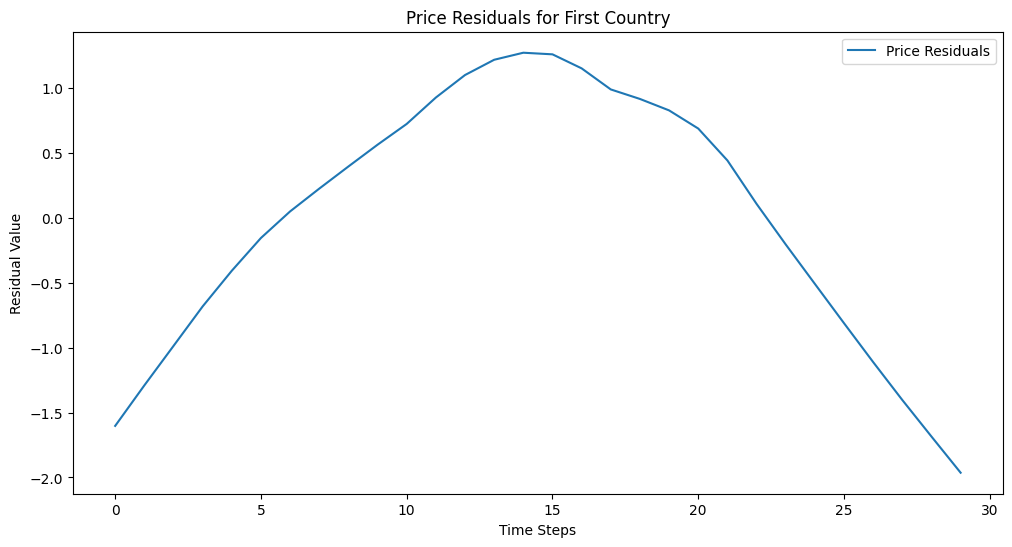

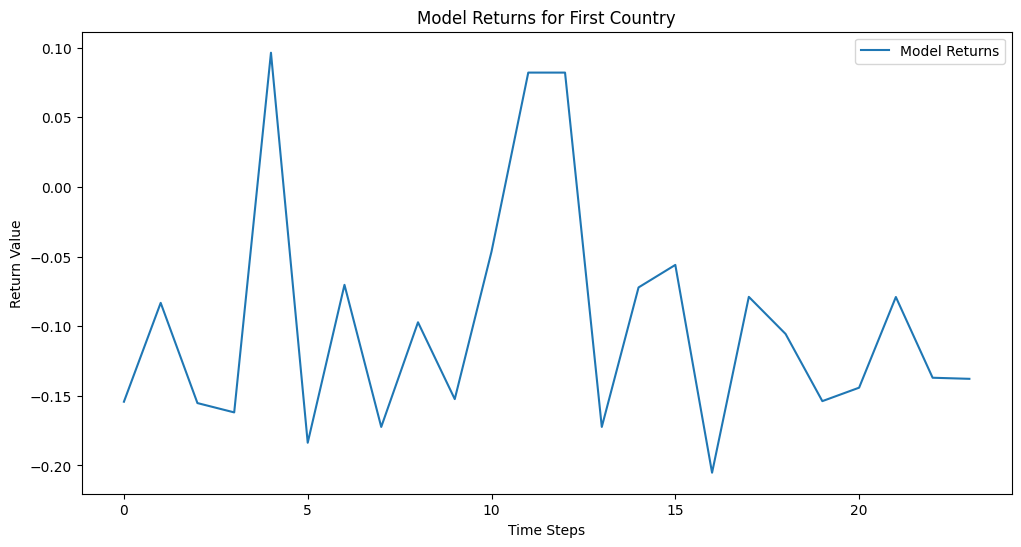

In [269]:
country_index = 0

# Get the first model input
first_model_input_without_weather = all_model_without_weather_inputs[country_index]

# Print the shape of the first model input
print(f"Shape of first model input without weather: {first_model_input_without_weather.shape}")  # [num_features, window_size]

# Plot the first countries' price residuals
import matplotlib.pyplot as plt
# Assuming the first country is at index 0
plt.figure(figsize=(12, 6))
plt.plot(first_model_input_without_weather[country_index, :], label='Price Residuals')
plt.title('Price Residuals for First Country')
plt.xlabel('Time Steps')
plt.ylabel('Residual Value')
plt.legend()
plt.show()

# Plot the model returns for a single country
plt.figure(figsize=(12, 6))
plt.plot(model_returns_without_weather_tensor[country_index].cpu().numpy(), label='Model Returns')
plt.title('Model Returns for First Country')
plt.xlabel('Time Steps')
plt.ylabel('Return Value')
plt.legend()
plt.show()


In [313]:
all_strategy_returns = []
all_portfolio_weights = []

strategy_returns = []
portfolio_weights_list = []

# Loop through each model_inputs_without_weather_tensor and model_returns_without_weather_tensor
for portfolio_optimizer in portfolio_optimizers_wow:
    strategy_returns = []
    portfolio_weights_list = []
    for model_input, model_return in zip(model_inputs_without_weather_tensor, model_returns_without_weather_tensor):    
            # Add batch dimension if needed
            if model_input.dim() == 2:
                model_input = model_input.unsqueeze(0)
            
            # Get portfolio weights from the optimizer
            weights = portfolio_optimizer.infer(model_input)
            
            # Add portfolio weights to the list
            portfolio_weights_list.append(weights.detach().cpu())

            # Squeeze to match shape if needed
            if weights.dim() > 1:
                weights = weights.squeeze(0)
            
            # Ensure shapes match
            if weights.shape != model_return.shape:
                raise ValueError(f"Shape mismatch: weights {weights.shape}, returns {model_return.shape}")
            
            # Calculate strategy returns
            strategy_return = (weights * model_return).sum().item()
            strategy_returns.append(strategy_return)

    # Append the strategy returns to the list
    all_strategy_returns.append(strategy_returns.copy())

    # Append the portfolio weights for this input
    all_portfolio_weights.append(portfolio_weights_list.copy())


Plot the backtest

In [314]:
def backtest_model_on_test_data(strategy_returns_plot, portfolio_weights_list_plot, strat_returns_title,\
                                 strat_cumsum_title, portfolio_weights_title):
    # # Plot the strategy returns
    # plt.figure(figsize=(12, 6))
    # plt.plot(strategy_returns_plot, label='Strategy Returns', color='blue')
    # plt.title(strat_returns_title)
    # plt.xlabel('Time Steps')
    # plt.ylabel('Cumulative Returns')
    # plt.legend()
    # plt.grid()
    # plt.show()

    # Plot the cumulative returns
    cumulative_strategy_returns = np.cumsum(strategy_returns_plot)
    plt.figure(figsize=(12, 6))
    plt.plot(cumulative_strategy_returns, label='Cumulative Strategy Returns', color='green')
    plt.title(strat_cumsum_title)
    plt.xlabel('Time Steps')
    plt.ylabel('Cumulative Returns')
    plt.legend()
    plt.grid()
    plt.show()

    # Plot the distribution of portfolio weights (not seperated by country but all together)
    portfolio_weights_tensor_plot = torch.stack(portfolio_weights_list_plot)
    plt.figure(figsize=(12, 6))
    plt.hist(portfolio_weights_tensor_plot.cpu().numpy().flatten(), bins=50, alpha=0.7, label='Portfolio Weights Distribution')
    plt.title(portfolio_weights_title)
    plt.xlabel('Weights')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid()
    plt.show()

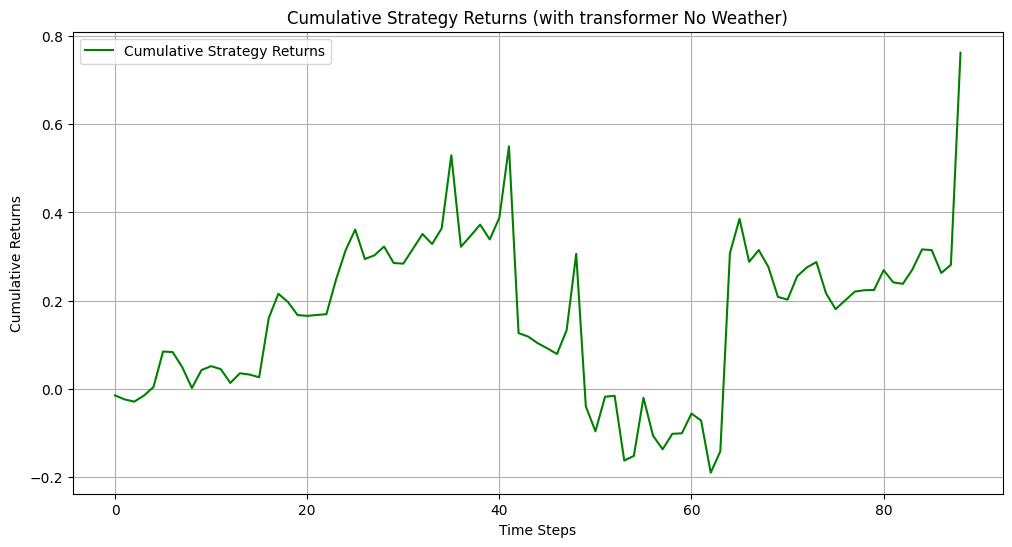

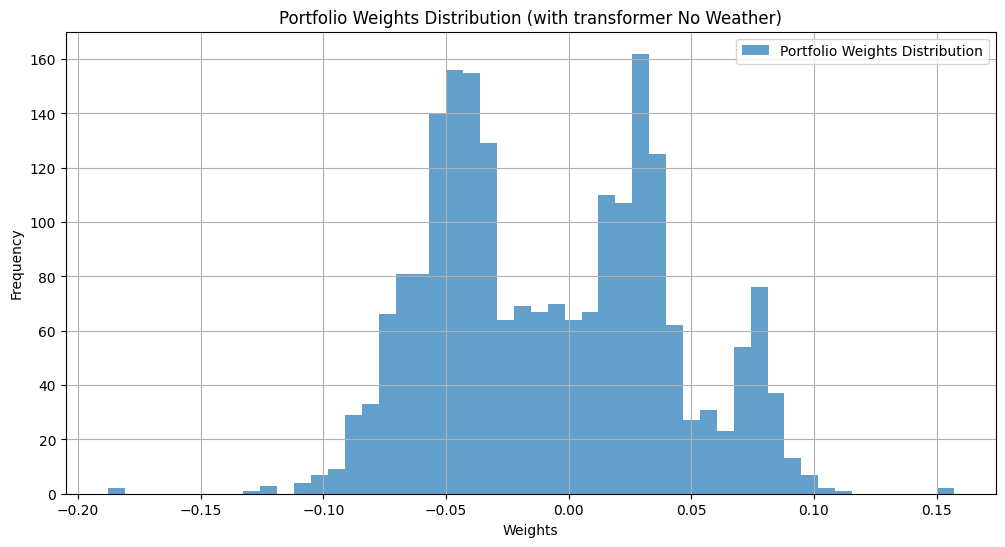

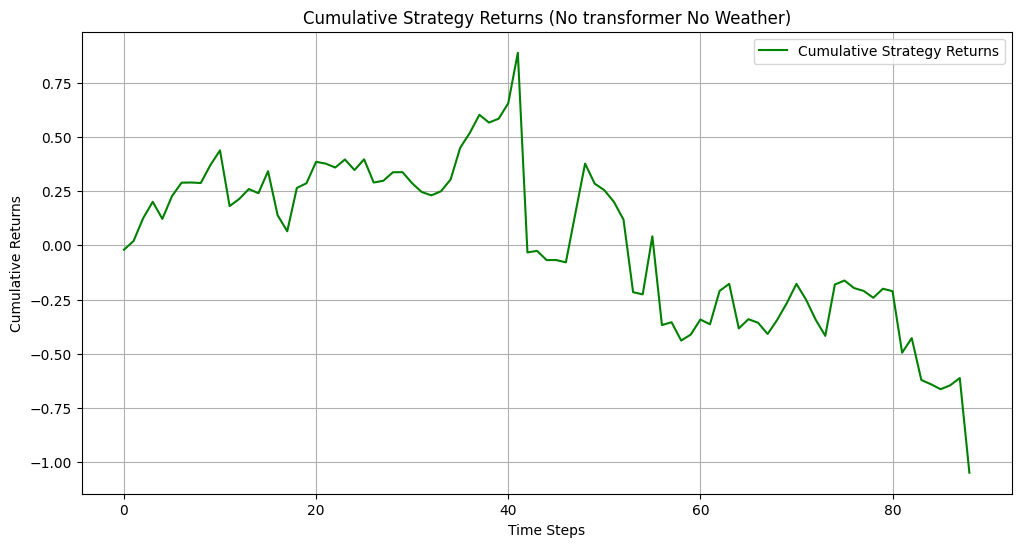

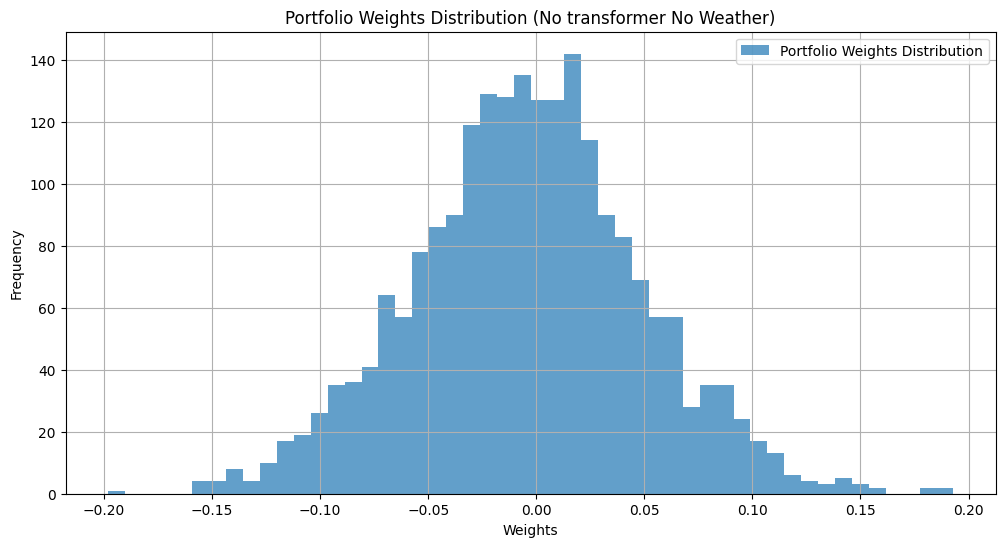

In [315]:
# # Split the portfolio optimizers into two list of no weather and with weather
# portfolio_optimizers_ww = [
#     portfolio_optimizer_wt_ww,
#     portfolio_optimizer_wot_ww
# ]

# portfolio_optimizers_wow = [
#     portfolio_optimizer_wt_wow,
#     portfolio_optimizer_wot_wow
# ]


# With transformer and without weather
strategy_returns_plot = all_strategy_returns[0]
portfolio_weights_list_plot = all_portfolio_weights[0]

backtest_model_on_test_data(
    strategy_returns_plot,
    portfolio_weights_list_plot,
    strat_returns_title="Strategy Returns (with transformer No Weather)",
    strat_cumsum_title="Cumulative Strategy Returns (with transformer No Weather)",
    portfolio_weights_title="Portfolio Weights Distribution (with transformer No Weather)"
)

# Without transformer and without weather
strategy_returns_plot = all_strategy_returns[1]
portfolio_weights_list_plot = all_portfolio_weights[1]

backtest_model_on_test_data(
    strategy_returns_plot,
    portfolio_weights_list_plot,
    strat_returns_title="Strategy Returns (No transformer No Weather)",
    strat_cumsum_title="Cumulative Strategy Returns (No transformer No Weather)",
    portfolio_weights_title="Portfolio Weights Distribution (No transformer No Weather)"
)


C:\Users\Volter\AppData\Local\Temp\ipykernel_40868\520038518.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample = torch.tensor(val_data_without_weather_tensor[0:1], dtype=torch.float32).to(device)


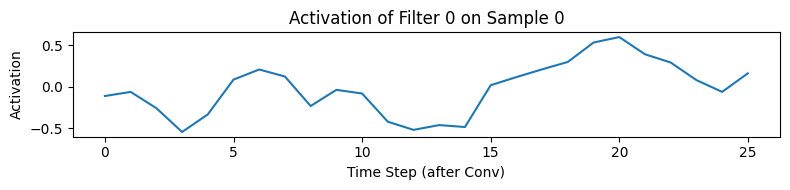

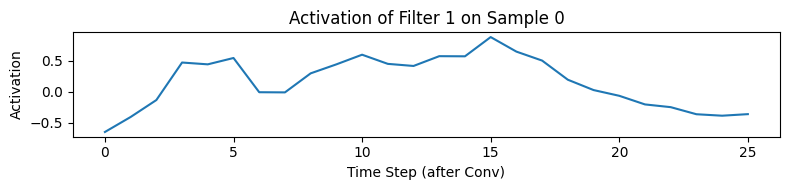

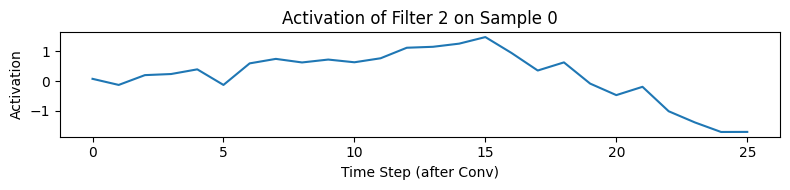

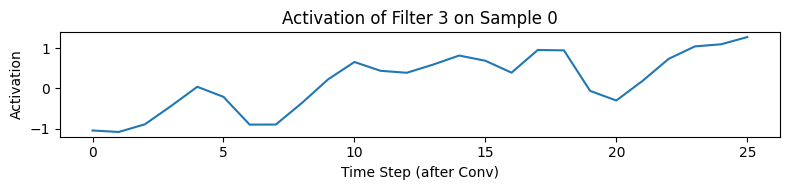

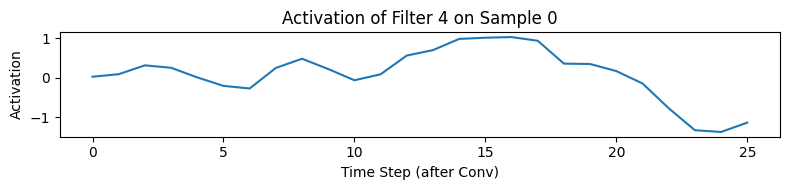

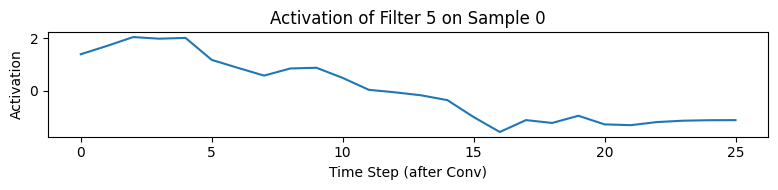

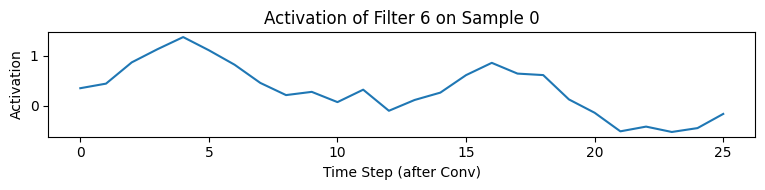

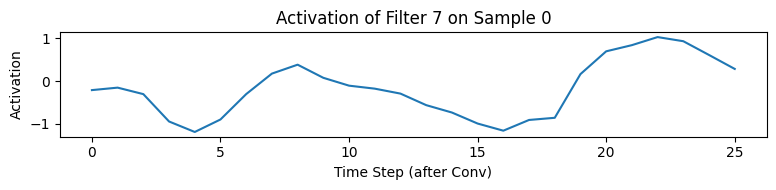

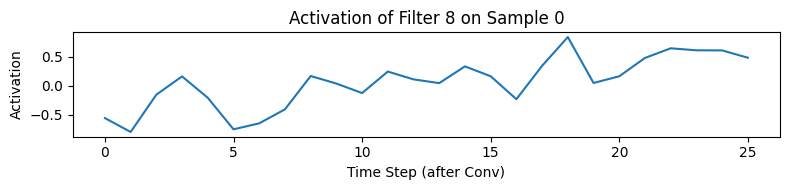

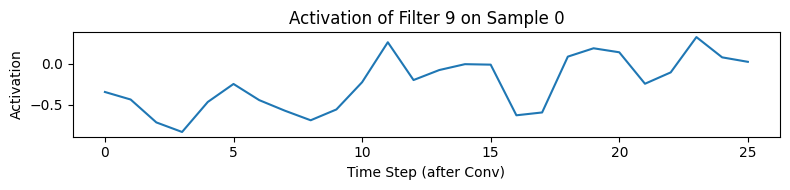

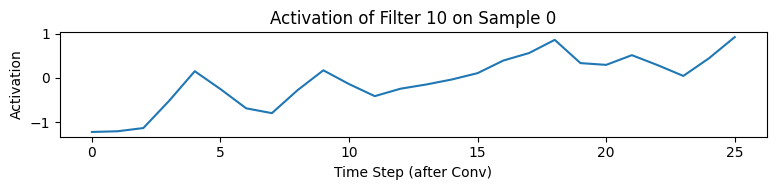

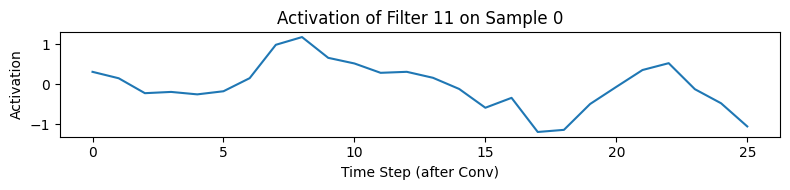

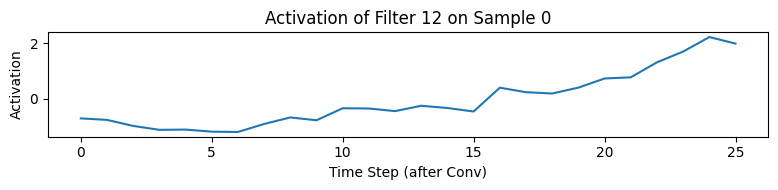

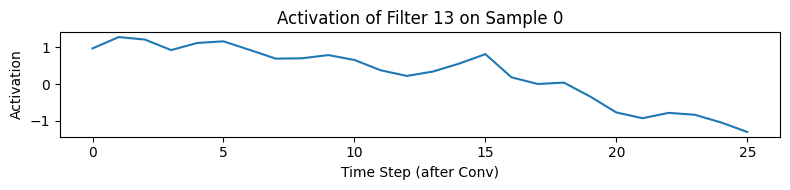

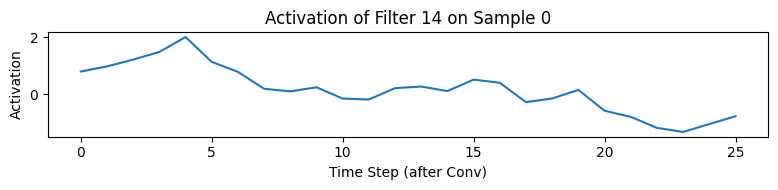

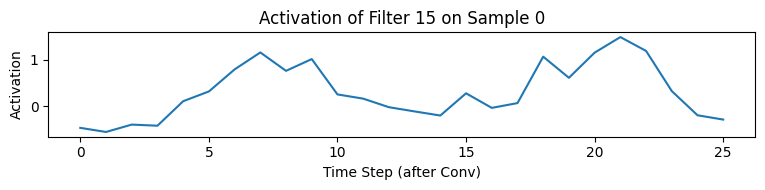

In [221]:
import matplotlib.pyplot as plt

# Choose a sample input (shape: [1, num_features, window_size])
sample = torch.tensor(val_data_without_weather_tensor[0:1], dtype=torch.float32).to(device)
portfolio_optimizer.cnn_model.eval()

with torch.no_grad():
    activations = portfolio_optimizer.cnn_model.conv1(sample)  # shape: [1, num_filters, output_width]

act = activations.squeeze(0).cpu().numpy()  # [num_filters, output_width]

for i in range(act.shape[0]):
    plt.figure(figsize=(8, 2))
    plt.plot(act[i])
    plt.title(f"Activation of Filter {i} on Sample 0")
    plt.xlabel("Time Step (after Conv)")
    plt.ylabel("Activation")
    plt.tight_layout()
    plt.show()


In [222]:
def overlay_input_and_activation(sample_input, model, sample_index=0, channel_index=0):
    """
    Overlay the input signal (for one channel/country) with the CNN activations
    to visualize which time regions trigger strong filter responses.

    Args:
        sample_input: torch.Tensor of shape [batch_size, num_features, window_size]
        model: portfolio_optimizer instance
        sample_index: which sample from batch to visualize
        channel_index: which input feature/country to visualize
    """
    device = next(model.cnn_model.parameters()).device
    model.cnn_model.eval()

    # Forward pass through CNN
    x = sample_input[sample_index:sample_index+1].to(device)
    with torch.no_grad():
        activations = model.cnn_model.conv1(x)  # [1, num_filters, conv_time]

    act = activations.squeeze(0).cpu().numpy()  # [num_filters, conv_time]
    input_signal = x[0, channel_index].cpu().numpy()  # [window_size]

    for i in range(act.shape[0]):
        plt.figure(figsize=(10, 3))
        plt.plot(input_signal, label=f"Input: Channel {channel_index}", alpha=0.7)

        upsampled = np.interp(np.linspace(0, len(act[i])-1, len(input_signal)),
                              np.arange(len(act[i])), act[i])
        upsampled = (upsampled - upsampled.min()) / (np.ptp(upsampled) + 1e-8)
        upsampled *= input_signal.max()

        plt.plot(upsampled, linestyle='--', label=f"Filter {i} Activation (rescaled)")
        plt.title(f"Overlay: Input Channel {channel_index} & CNN Filter {i} Activation")
        plt.xlabel("Time Index")
        plt.ylabel("Value")
        plt.legend()
        plt.tight_layout()
        plt.show()


C:\Users\Volter\AppData\Local\Temp\ipykernel_40868\1209910249.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample = torch.tensor(val_data_without_weather_tensor[0:1], dtype=torch.float32)


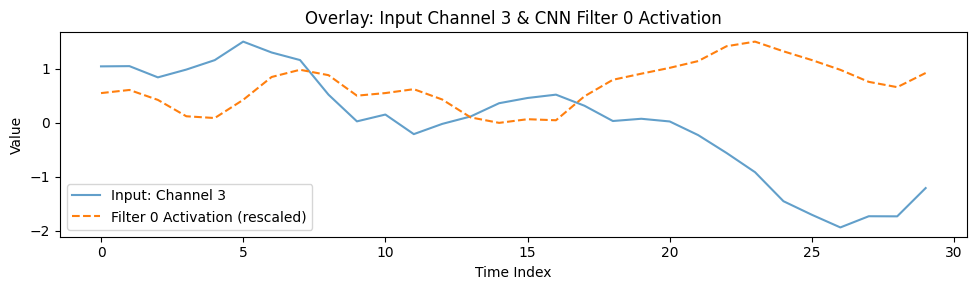

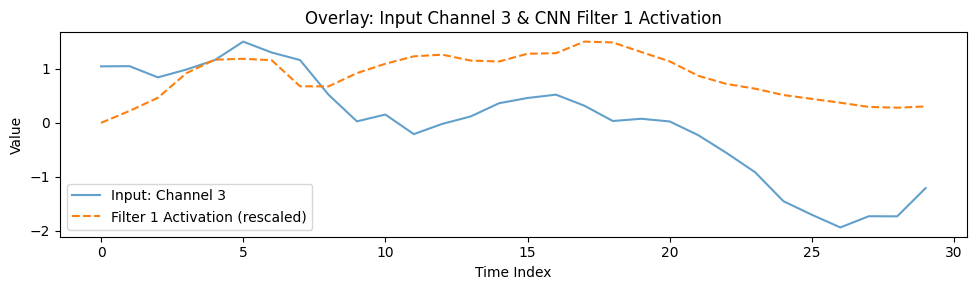

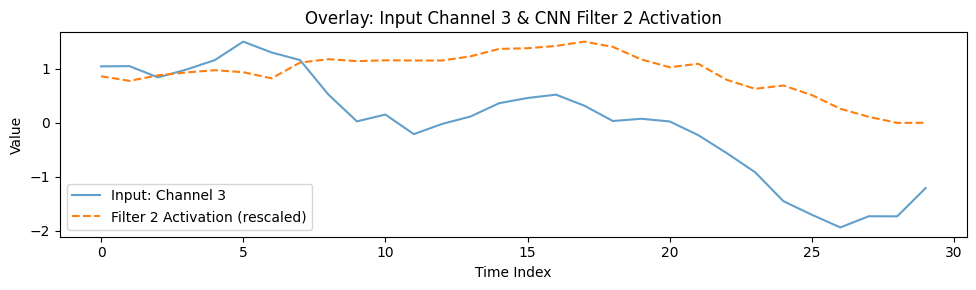

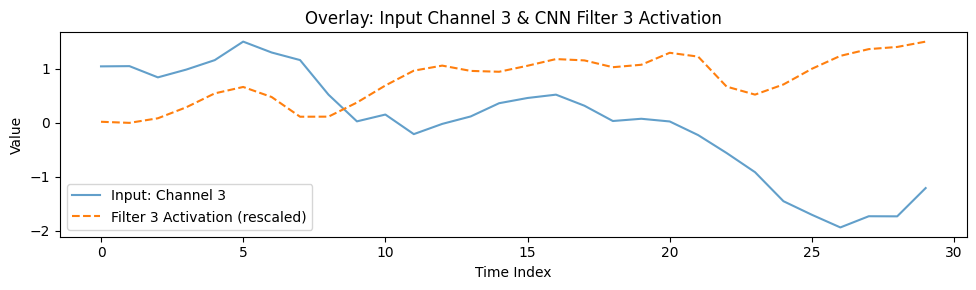

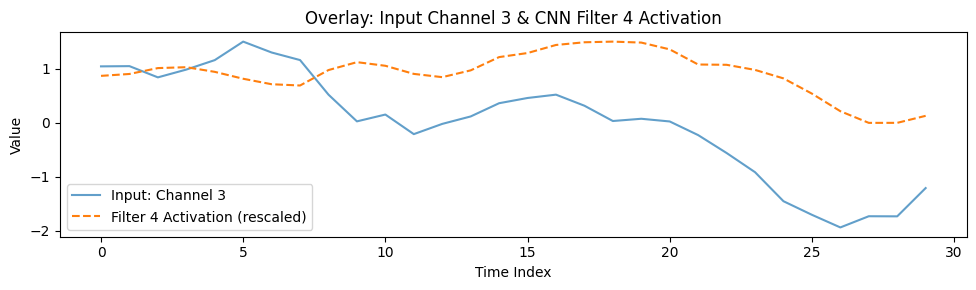

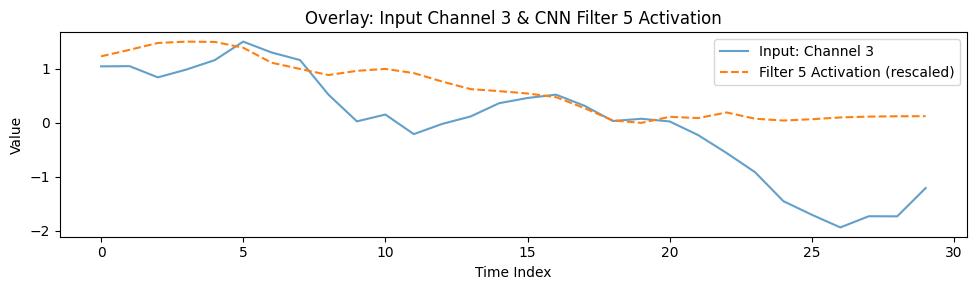

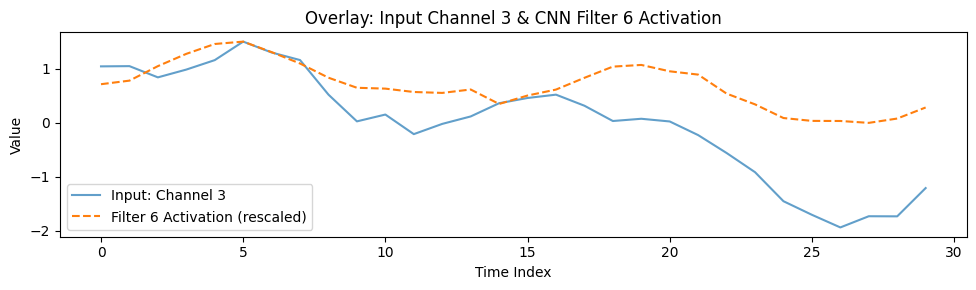

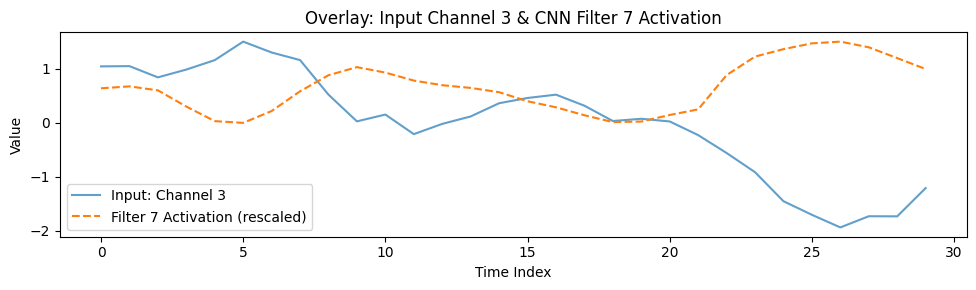

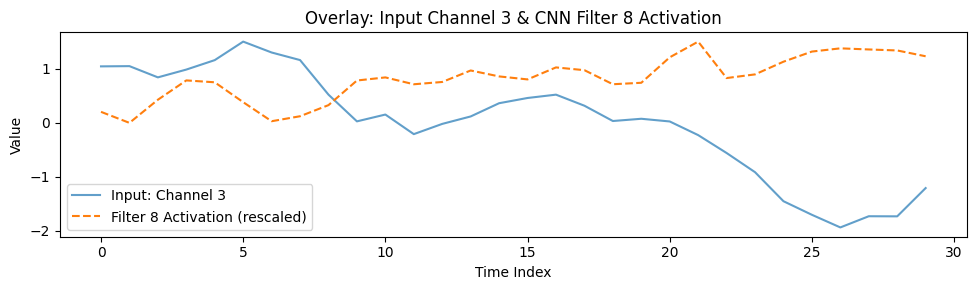

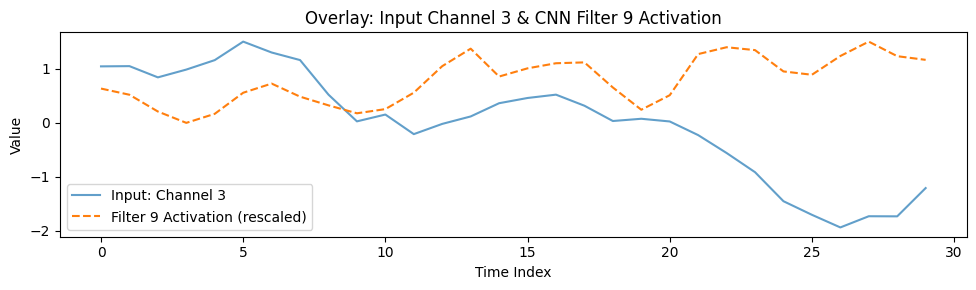

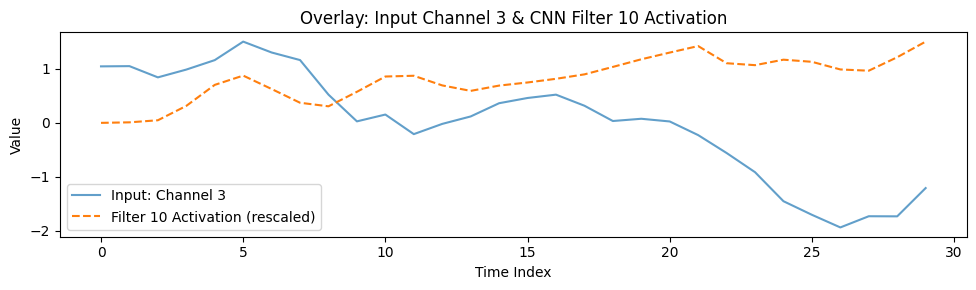

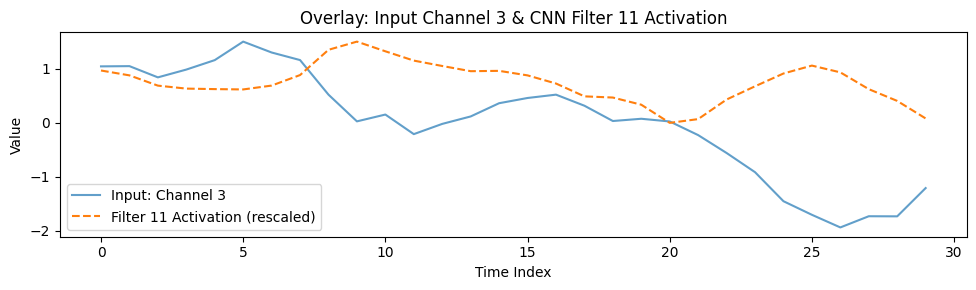

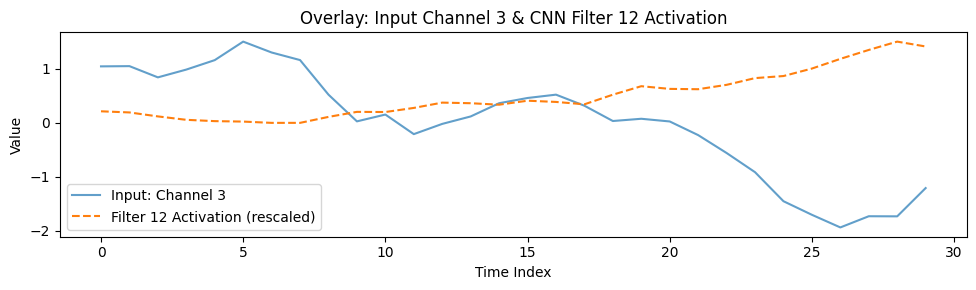

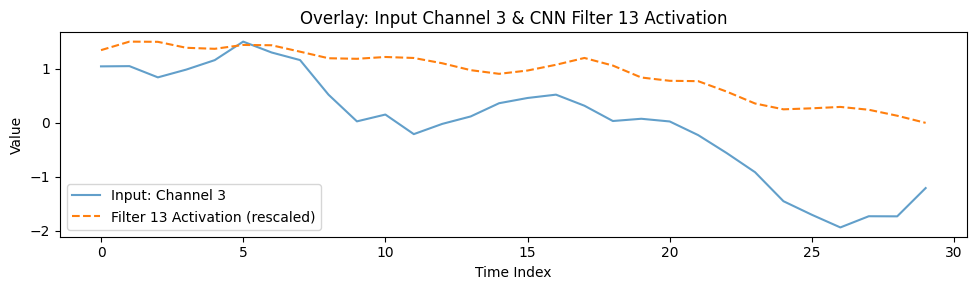

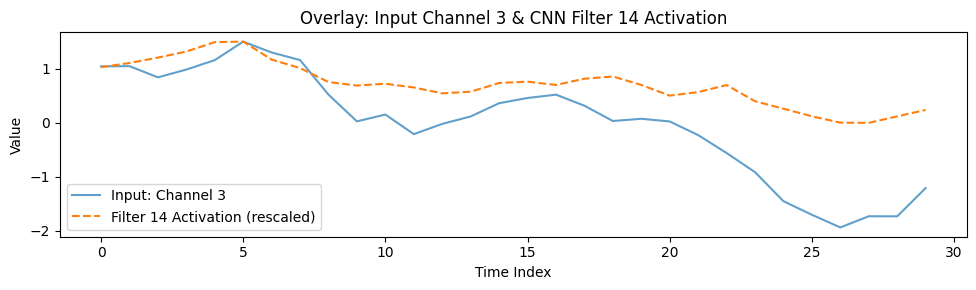

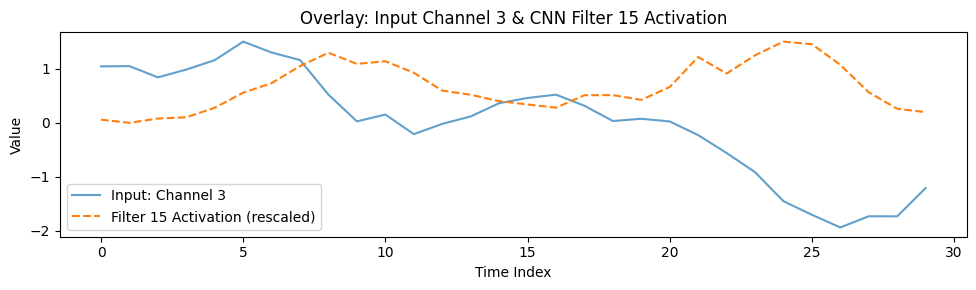

In [223]:
sample = torch.tensor(val_data_without_weather_tensor[0:1], dtype=torch.float32)
overlay_input_and_activation(sample, portfolio_optimizer, sample_index=0, channel_index=3)


#### Correlation matrix for Electricity Prices

In [224]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from PriceDataLoader import PriceDataLoader

def plot_log_cumulative_return_correlation_with_loader(
    price_loader: PriceDataLoader,
    time_range: str,
    countries: list[str],
    fill_method: str = "ffill"
):
    """
    Uses PriceDataLoader to compute and visualize the correlation matrix
    of log cumulative returns for specified countries and date range.

    Args:
        price_loader (PriceDataLoader): Instance of the loader class.
        time_range (str): e.g., '2015-01-01,2024-12-31'
        countries (list[str]): List of countries to include in correlation matrix.
        fill_method (str): 'ffill', 'bfill', or None.
    """
    # Get price matrix [Date x Country]
    price_matrix = price_loader.get_price_matrix(time_range, countries, fill_method=fill_method)

    if price_matrix.empty:
        print("Error: Price matrix is empty. Check countries or date range.")
        return

    # Compute log cumulative returns
    log_prices = np.log(price_matrix)
    log_cum_returns = log_prices - log_prices.iloc[0]

    # Compute correlation matrix
    corr = log_cum_returns.corr()

    # Plot
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, cmap="coolwarm", square=True, linewidths=0.5)
    plt.title("Correlation Matrix of Log Cumulative Returns")
    plt.tight_layout()
    plt.show()

Data loaded successfully from ../data/european_wholesale_electricity_price_data_daily.csv


c:\Users\Volter\anaconda3\envs\DeepLearningSTAT7007\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


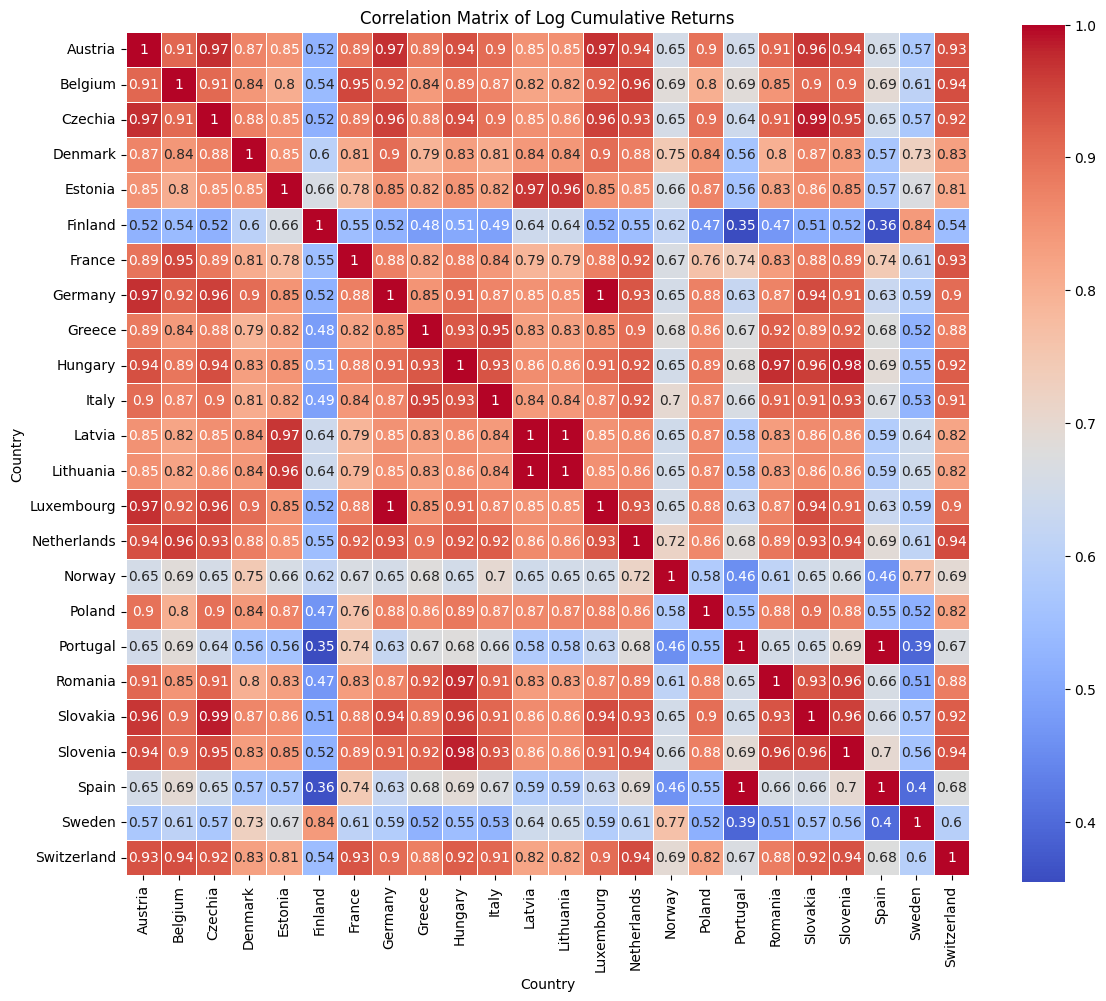

In [225]:
price_loader = PriceDataLoader()
countries = countries_list  # Use the list of countries from earlier
time_range = "2015-01-01,2024-12-31"
plot_log_cumulative_return_correlation_with_loader(price_loader, time_range, countries)

In [226]:
df = pd.read_csv("../data/european_wholesale_electricity_price_data_daily.csv")
print(df.columns.tolist())
df.head()

['Country', 'ISO3 Code', 'Date', 'Price (EUR/MWhe)']


,Country,ISO3 Code,Date,Price (EUR/MWhe)
0,Austria,AUT,2015-01-01,22.34
1,Belgium,BEL,2015-01-01,36.56
2,Czechia,CZE,2015-01-01,20.60
3,Denmark,DNK,2015-01-01,15.51
4,Estonia,EST,2015-01-01,24.51
